In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

df = pd.DataFrame(pd.read_csv("maplefreight_delivery_delay_dataset.csv"))

In [40]:
df.head()

,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


In [41]:
df.describe()


,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
count,6035.000000,6035.000000,6.035000e+03,6035.000000,6035.000000,6035.000000,6035.000000,5825.000000,6035.000000,5914.000000,6035.000000,6035.000000,5795.000000,6035.000000,6035.000000
mean,6.543662,632.192742,6.928251e+03,2.477051,0.113007,10.500388,20.367688,6.497648,5.489461,55.146365,0.449778,1.305551,180.696552,11.186038,0.205800
std,3.448260,319.246133,8.375515e+04,1.707457,0.316628,4.758576,30.618617,4.659277,3.433676,17.592978,0.194500,1.158943,58.759928,5.957114,0.404318
min,1.000000,80.500000,3.000000e+01,0.000000,0.000000,1.000000,-20.000000,0.200000,0.100000,5.000000,0.000000,0.000000,30.000000,0.880000,0.000000
25%,4.000000,398.600000,4.960000e+02,1.000000,0.000000,7.060000,-6.000000,3.200000,3.000000,43.300000,0.318000,0.000000,140.595000,7.080000,0.000000
50%,7.000000,571.100000,8.271000e+02,2.000000,0.000000,9.850000,18.000000,5.400000,4.800000,55.000000,0.446000,1.000000,181.180000,10.050000,0.000000
75%,10.000000,804.850000,1.286300e+03,4.000000,0.000000,13.175000,41.000000,8.600000,7.200000,67.200000,0.583000,2.000000,220.950000,14.010000,0.000000
max,12.000000,2556.700000,2.999300e+06,5.000000,1.000000,37.400000,146.000000,35.000000,20.000000,100.000000,1.000000,8.000000,392.010000,55.380000,1.000000


In [42]:
df.dtypes

shipment_id                      str
origin_city                      str
destination_city                 str
carrier                          str
service_level                    str
goods_type                       str
customer_priority_tier           str
shipment_month                 int64
distance_km                  float64
weight_kg                    float64
num_stops                      int64
is_cross_border                int64
scheduled_transit_hours      float64
pickup_delay_minutes         float64
driver_experience_years      float64
vehicle_age_years            float64
weather_condition                str
traffic_index                float64
route_congestion_score       float64
prior_late_deliveries_30d      int64
fuel_cost_cad                float64
actual_transit_hours         float64
delivered_late                 int64
dtype: object

In [43]:
null_values = df.isnull().sum()
null_values

shipment_id                    0
origin_city                    0
destination_city               0
carrier                        0
service_level                  0
goods_type                     0
customer_priority_tier         0
shipment_month                 0
distance_km                    0
weight_kg                      0
num_stops                      0
is_cross_border                0
scheduled_transit_hours        0
pickup_delay_minutes           0
driver_experience_years      210
vehicle_age_years              0
weather_condition            150
traffic_index                121
route_congestion_score         0
prior_late_deliveries_30d      0
fuel_cost_cad                240
actual_transit_hours           0
delivered_late                 0
dtype: int64

In [44]:
all_duplicate_rows = df[df.duplicated(keep=False)]
all_duplicate_rows

,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
10,SHP-102224,Calgary AB,Quebec City QC,MapleFreight Fleet,Standard,Bulk,Silver,9,495.2,3993.1,...,-20.0,2.6,1.8,Clear,20.1,0.463,0,251.70,8.23,0
169,SHP-100457,Montreal QC,Toronto ON,PrairieLine,Economy,General Freight,Silver,8,532.1,1113.3,...,26.0,20.2,4.6,Clear,66.3,0.691,0,115.19,8.49,0
192,SHP-104541,London ON,Ottawa ON,NorthStar Carriers,Standard,General Freight,Gold,11,608.8,637.0,...,-1.0,3.1,3.8,Clear,62.7,0.441,1,193.43,8.97,0
210,SHP-103447,Toronto ON,Calgary AB,MapleFreight Fleet,Standard,Bulk,Bronze,11,430.5,1018.4,...,5.0,4.9,9.3,Snow,24.2,0.468,3,106.86,10.49,0
307,SHP-105761,Mississauga ON,Montreal QC,NorthStar Carriers,Standard,Refrigerated,Bronze,6,303.7,68.9,...,31.0,8.0,2.5,Clear,43.0,0.723,1,235.19,11.98,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5623,SHP-104960,Toronto ON,Hamilton ON,NorthStar Carriers,Express,General Freight,Silver,2,895.3,386.1,...,14.0,0.3,7.1,Clear,46.5,0.653,1,210.55,13.72,0
5694,SHP-101239,Ottawa ON,Ottawa ON,MapleFreight Fleet,Standard,Bulk,Silver,8,881.7,2018.4,...,-12.0,4.3,11.0,Rain,57.0,0.260,1,191.63,14.12,0
5754,SHP-101514,Montreal QC,Edmonton AB,QuebecExpress,Economy,General Freight,Silver,8,1178.6,2111.5,...,34.0,4.2,4.8,Clear,48.0,0.278,0,248.53,17.31,0
5956,SHP-101843,Mississauga ON,Montreal QC,MapleFreight Fleet,Standard,Refrigerated,Bronze,1,913.8,2263.8,...,112.0,5.2,11.7,Clear,47.5,0.610,2,108.01,20.65,1


### Data Cleaning

In [45]:
def clean_data(df):
    # Drop duplicates
    df = df.drop_duplicates()
    # Impute Using Median for Numerical Columns
    for col in df.select_dtypes(include=np.number):
        df[col] = df[col].fillna(df[col].median())

    return df



df_cleaned = clean_data(df)
print("Cleaned DataFrame:")
print(df_cleaned)


Cleaned DataFrame:
     shipment_id     origin_city destination_city             carrier  \
0     SHP-103848  Mississauga ON      Edmonton AB  NorthStar Carriers   
1     SHP-102827     Montreal QC      Winnipeg MB         PrairieLine   
2     SHP-105254      Toronto ON      Hamilton ON       QuebecExpress   
3     SHP-102719     Montreal QC      Hamilton ON  MapleFreight Fleet   
4     SHP-105198  Mississauga ON       Sudbury ON  MapleFreight Fleet   
...          ...             ...              ...                 ...   
6030  SHP-101294       London ON   Quebec City QC       QuebecExpress   
6031  SHP-104024  Mississauga ON      Montreal QC  MapleFreight Fleet   
6032  SHP-105201     Montreal QC       Toronto ON  MapleFreight Fleet   
6033  SHP-103776       Ottawa ON   Quebec City QC  MapleFreight Fleet   
6034  SHP-101946      Toronto ON        Regina SK  MapleFreight Fleet   

     service_level       goods_type customer_priority_tier  shipment_month  \
0         Standard  Genera

In [46]:
df_cleaned.describe()

,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
count,6003.000000,6003.000000,6.003000e+03,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000,6003.000000
mean,6.541229,632.131901,6.959216e+03,2.474596,0.112610,10.497223,20.347826,6.466700,5.492570,55.142212,0.449785,1.305347,180.623841,11.183738,0.205730
std,3.448158,319.362781,8.397703e+04,1.707193,0.316142,4.760570,30.605033,4.584042,3.435431,17.420227,0.194655,1.159067,57.576470,5.962353,0.404268
min,1.000000,80.500000,3.000000e+01,0.000000,0.000000,1.000000,-20.000000,0.200000,0.100000,5.000000,0.000000,0.000000,30.000000,0.880000,0.000000
25%,4.000000,398.450000,4.959500e+02,1.000000,0.000000,7.060000,-6.000000,3.300000,3.000000,43.500000,0.317500,0.000000,142.720000,7.080000,0.000000
50%,7.000000,571.100000,8.271000e+02,2.000000,0.000000,9.830000,18.000000,5.400000,4.800000,55.000000,0.446000,1.000000,181.150000,10.060000,0.000000
75%,10.000000,804.500000,1.286300e+03,4.000000,0.000000,13.170000,41.000000,8.500000,7.200000,67.000000,0.583000,2.000000,218.760000,14.010000,0.000000
max,12.000000,2556.700000,2.999300e+06,5.000000,1.000000,37.400000,146.000000,35.000000,20.000000,100.000000,1.000000,8.000000,392.010000,55.380000,1.000000


In [47]:
df_cleaned[df_cleaned.duplicated(keep=False)]

,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late


In [48]:
df_cleaned[df_cleaned["delivered_late"] == 1].describe()


,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
count,1235.000000,1235.000000,1.235000e+03,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.000000,1235.0
mean,6.378138,748.510526,8.269614e+03,2.991903,0.133603,12.458016,27.910931,5.647368,5.915951,60.772146,0.487763,1.547368,181.590356,16.973368,1.0
std,3.554896,364.728991,8.029315e+04,1.640235,0.340363,5.225822,30.456231,3.935139,3.718727,16.819604,0.198136,1.201693,56.754731,7.474880,0.0
min,1.000000,105.700000,3.000000e+01,0.000000,0.000000,1.000000,-20.000000,0.200000,0.100000,9.400000,0.000000,0.000000,30.000000,1.170000,1.0
25%,3.000000,473.000000,4.875000e+02,2.000000,0.000000,8.825000,4.000000,2.750000,3.200000,48.600000,0.341000,1.000000,145.205000,11.720000,1.0
50%,6.000000,689.000000,8.520000e+02,3.000000,0.000000,11.730000,28.000000,4.800000,5.100000,60.700000,0.486000,1.000000,181.150000,15.840000,1.0
75%,9.500000,951.950000,1.369050e+03,4.000000,0.000000,15.410000,48.000000,7.600000,7.750000,72.750000,0.621500,2.000000,221.010000,20.915000,1.0
max,12.000000,2556.700000,1.227100e+06,5.000000,1.000000,37.400000,134.000000,28.000000,20.000000,100.000000,1.000000,7.000000,343.290000,55.380000,1.0


In [49]:
df_cleaned[df_cleaned["delivered_late"] == 0].describe()

,shipment_month,distance_km,weight_kg,num_stops,is_cross_border,scheduled_transit_hours,pickup_delay_minutes,driver_experience_years,vehicle_age_years,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
count,4768.000000,4768.000000,4.768000e+03,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4768.0
mean,6.583473,601.987689,6.619799e+03,2.340604,0.107173,9.989341,18.388842,6.678922,5.382907,53.683956,0.439948,1.242659,180.373496,9.684117,0.0
std,3.419081,299.269971,8.491002e+04,1.698780,0.309365,4.495664,30.340716,4.714861,3.349857,17.277528,0.192546,1.139544,57.790665,4.400287,0.0
min,1.000000,80.500000,3.130000e+01,0.000000,0.000000,1.000000,-20.000000,0.200000,0.100000,5.000000,0.000000,0.000000,30.000000,0.880000,0.0
25%,4.000000,382.550000,4.986750e+02,1.000000,0.000000,6.760000,-7.000000,3.400000,2.900000,42.400000,0.310000,0.000000,141.992500,6.557500,0.0
50%,7.000000,547.900000,8.216500e+02,2.000000,0.000000,9.400000,16.000000,5.400000,4.700000,53.900000,0.436000,1.000000,181.150000,9.080000,0.0
75%,10.000000,764.350000,1.263700e+03,4.000000,0.000000,12.582500,39.000000,8.800000,7.100000,65.300000,0.572000,2.000000,218.260000,12.132500,0.0
max,12.000000,2184.900000,2.999300e+06,5.000000,1.000000,33.600000,146.000000,35.000000,20.000000,100.000000,1.000000,8.000000,392.010000,34.240000,0.0


In [50]:
print(df_cleaned["delivered_late"].value_counts())
print(df_cleaned["delivered_late"].value_counts(normalize=True))

delivered_late
0    4768
1    1235
Name: count, dtype: int64
delivered_late
0    0.79427
1    0.20573
Name: proportion, dtype: float64


#### Dropping shipment_id, delivered_late, actual_transit_hours since Shipment is just for identification.
#### actual_transit_hours is recorded on delivery and not available at prediction time
#### delivered_late is the Target so we can remove it.

##### Use a stratified split because of the 21/79 imbalance.

In [51]:
X = df.drop(columns=["delivered_late", "actual_transit_hours"])
y = df["delivered_late"]
X = X.drop(columns=["shipment_id"])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

stratify=y

In [52]:
categorical_features = [
    "origin_city",
    "destination_city",
    "carrier",
    "service_level",
    "goods_type",
    "customer_priority_tier",
    "weather_condition"
]

numeric_features = [
    "shipment_month",
    "distance_km",
    "weight_kg",
    "num_stops",
    "is_cross_border",
    "scheduled_transit_hours",
    "pickup_delay_minutes",
    "driver_experience_years",
    "vehicle_age_years",
    "traffic_index",
    "route_congestion_score",
    "prior_late_deliveries_30d",
    "fuel_cost_cad"
]

#### Imputing using the median 

In [53]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [54]:
class_weight="balanced"

In [55]:
from sklearn.linear_model import LogisticRegression

baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000
    ))
])

baseline.fit(X_train, y_train)

c:\Users\Andrew\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['origin_city','destination_city','carrier',...,'route_congestion_score', 'prior_late_deliveries_30d','fuel_cost_cad']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).

In [56]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

y_pred = baseline.predict(X_test)

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Precision: 0.3228200371057514
Recall: 0.7016129032258065
F1: 0.44218551461245237

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.62      0.73       959
           1       0.32      0.70      0.44       248

    accuracy                           0.64      1207
   macro avg       0.61      0.66      0.59      1207
weighted avg       0.77      0.64      0.67      1207



In [57]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[594 365]
 [ 74 174]]


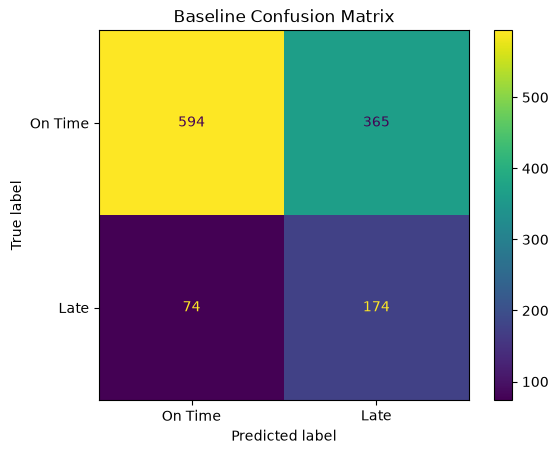

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["On Time", "Late"]
)

plt.title("Baseline Confusion Matrix")
plt.show()

In [59]:
from sklearn.ensemble import RandomForestClassifier

random_forest = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_test)

In [60]:
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Precision: 0.5925925925925926
Recall: 0.3870967741935484
F1: 0.4682926829268293
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       959
           1       0.59      0.39      0.47       248

    accuracy                           0.82      1207
   macro avg       0.72      0.66      0.68      1207
weighted avg       0.80      0.82      0.80      1207



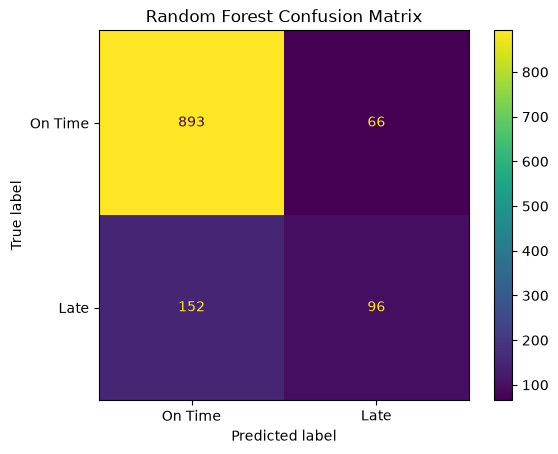

In [61]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["On Time", "Late"]
)

plt.title("Random Forest Confusion Matrix")
plt.show()

In [62]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Precision,Recall,F1
0,Logistic Regression,0.322820,0.701613,0.442186
1,Random Forest,0.592593,0.387097,0.468293


In [63]:
class_weight="balanced"